# Tracking neurons from neuron detection
This notebook represents a basic, commented process of 
1) reading and storing results from neuron detection (e.g. CaImAn)
2) building a probabilistic model for neuron tracking
3) registering footprints to neuron identities
4) finally, plotting some results

## Preparations

#### Loading general and module-specific dependencies 

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
from tqdm.auto import tqdm


In [ ]:
## catan specific imports
from catan import Tracking, TrackingAnalysis

#### Setting up paths
The tracking algorithm itself is agnostic the exact folder structure, but requires a path to a neuron detection result for each session that should be loaded and processed.

In our case, we define a root path (for one mouse) and find paths automatically, assuming their alphabetical order represents a chronological order, e.g. when the result files are stored as 
```
- path/to/mouse/data/
   | - Session01 / neuron_detection*
   | - Session02 / neuron_detection*
   | - ...
```

In [ ]:
mouse_path = Path("path/to/mouse/data")
paths = sorted(Path(mouse_path).glob("*/neuron_detection*"))

#### Initialize tracking class
Set up the class for session loading, model building and registration

All of this is done within the same class, reusing calculated properties in an efficient manner to allow quick processing.

In [5]:
mm = Tracking(
    neighbor_distance=25.0,
    bins=64,
    n_threads=1,
    use_kde=False,
    pxtomu=536.0 / 512.0,  # imaging window length / number pixels
)

# Processing neuron detection results

## Session data registration
Iterating through the predefined sessions in `paths`, `Tracking.register_session(path)` reads in all relevant data from neuron detection results (e.g. from CaImAn) and preprocesses it into a `SessionData`, which can be accessed from `mm.sessions[id]`, `id` being the integer order in which sessions were registered (if not changed later).

If `align` is not set to False, this also performs alignment with all previously registered sessions (highly encouraged!)

`SessionData` is one of the central structures in all methods of CATAN

In [6]:
path_iteration = tqdm(paths, desc="Registering sessions")
for i, path in enumerate(path_iteration):
    path_iteration.set_description(
        f"Registering session {i+1}/{len(paths)}: {path.name}"
    )

    mm.register_session(
        from_file=path, load_content=["quality", "spatial", "temporal"], align=True
    )

    if i >= 10:
        break

Registering sessions:   0%|          | 0/60 [00:00<?, ?it/s]

## Build Model
Using `update_model_with_data()`, `Tracking` registers counts for computed similarity and distance values of all neuron pairs within `neighbor_distance` $\mu m$.

Input can either come from a preregistered session (encouraged), providing the session id to `from_session_id`, directly from a file, providing its path to `from_file`, or from a `SessionData` object, providing the class instance to `from_data`.

For details on calculating the statistics, see the demo notebook `statistics.ipynb`


In [ ]:
mm.reset_model()
for i in tqdm(range(len(mm.sessions))):
    mm.update_model_with_data(from_session_id=i)

  0%|          | 0/11 [00:00<?, ?it/s]

calculating footprint correlation of 223 neurons:   0%|          | 0/223 [00:00<?, ?it/s]

calculating footprint correlation of 162 neurons:   0%|          | 0/162 [00:00<?, ?it/s]

calculating footprint correlation of 220 neurons:   0%|          | 0/223 [00:00<?, ?it/s]

calculating footprint correlation of 243 neurons:   0%|          | 0/243 [00:00<?, ?it/s]

...

calculating footprint correlation of 378 neurons:   0%|          | 0/382 [00:00<?, ?it/s]

calculating footprint correlation of 414 neurons:   0%|          | 0/414 [00:00<?, ?it/s]

calculating footprint correlation of 524 neurons:   0%|          | 0/525 [00:00<?, ?it/s]

calculating footprint correlation of 484 neurons:   0%|          | 0/484 [00:00<?, ?it/s]

calculating footprint correlation of 413 neurons:   0%|          | 0/414 [00:00<?, ?it/s]

### Fitting the distance-similarity model
The cumulated counts from all registered sessions are used as empirical data to fit the probabilistic model to. 

#### The probabilistic model
... consists of a same-neuron and different neuron distribution for the distance (of optimal shift) and similarity value.

Distance distributions are calculated by a noisy matern-hard core model (different) and Rayleigh distribution (same).

Correlation distributions are assumed to be gaussian (different) and reverse lognormal (same).

#### Initial estimates 
... of parameters are obtained from according subsections of the count distribution and usually result in a good first guess. If the fit fails (sometimes happens with few data), the model defaults to the initial estimates.

#### Match probability
... is evaluated from a 2D model of both populations (same and different), which is calculated from dist[:,None]*corr[None,:] and weighted by the estimated fraction of same vs different neurons. The probability of a footprint being assigned to the same neuron as another one is pdf_same / pdf_total.

For better results, the model uses the direction-adjusted cdf instead of the pdf. For the *same* model, the distance pdf runs from far distances (cdf=0) to zero distance (cdf=1) and for the correlation model from 0 correlation (cdf=0) to perfect correlation (cdf=1). The distance model cdf runs into the opposite direction, for both models.

In [ ]:
mm.fit_to_model(use_cdf=True)

## Registration of footprints to neurons
The algorithm iteratively goes through the registered sessions and assigns neurons in the `union` SessionData object.

The first session registers all neurons as new neurons to `union`.

Then, for each session:
* evaluate distance and similarity of all footprints to closeby union-footprints
* obtain matching probability
* assign neurons using a thresholded Hungarian algorithm (*cost opimized match*) with matches considered only above p_thr
* update union footprints with matched footprints using a probability-weighted sum (less update if match probability is low)
* register unmatched footprints as new neurons to `union`

This is repeated up to the last session

In [11]:
mm.reset_registration()
for i in tqdm(range(len(mm.sessions))):
    mm.register_neurons(from_session_id=i)

  0%|          | 0/11 [00:00<?, ?it/s]

calculating footprint correlation of 220 neurons:   0%|          | 0/220 [00:00<?, ?it/s]

calculating footprint correlation of 328 neurons:   0%|          | 0/328 [00:00<?, ?it/s]

calculating footprint correlation of 443 neurons:   0%|          | 0/443 [00:00<?, ?it/s]

calculating footprint correlation of 574 neurons:   0%|          | 0/574 [00:00<?, ?it/s]

...

calculating footprint correlation of 807 neurons:   0%|          | 0/807 [00:00<?, ?it/s]

calculating footprint correlation of 874 neurons:   0%|          | 0/874 [00:00<?, ?it/s]

calculating footprint correlation of 914 neurons:   0%|          | 0/914 [00:00<?, ?it/s]

calculating footprint correlation of 974 neurons:   0%|          | 0/974 [00:00<?, ?it/s]

calculating footprint correlation of 1000 neurons:   0%|          | 0/1000 [00:00<?, ?it/s]

## Save results
Both the calculated model and the registration results can be saved to an hdf5, using the integrated `to_hdf5()` methods.

The path of the saved files defaults to a `matching` folder in the common path of all sessions, if none is provided and is named `match_model.hdf5` and `neuron_registration.hdf5` if not specified.

In [ ]:
mm.save_model()
mm.save_registration()

## Visualizing results
The class `TrackingAnalysis` extends `Tracking` with a bunch of useful matplotlib plots that show the results of the model building and neuron registration.

It can load the previously saved data using the integrated `from_hdf5()` methods.

In [ ]:
m = TrackingAnalysis()

path_tracking = Path("path/to/mouse/data")
m.load_model(path_tracking / "match_model.hdf5")
m.load_registration(path_tracking / "neuron_registration.hdf5")

### Registration visualizations

In [ ]:
## displays the rigid alignment between two sessions
m.plot_alignment_statistics(5, 6)

### Model building results

In [ ]:
## display the registered count-histograms
m.plot_count_histogram()

In [ ]:
# display the model fit results along with the
# registered counts and resulting match probability
m.plot_model()

## Neuron registration results

735 clusters, 11 sessions


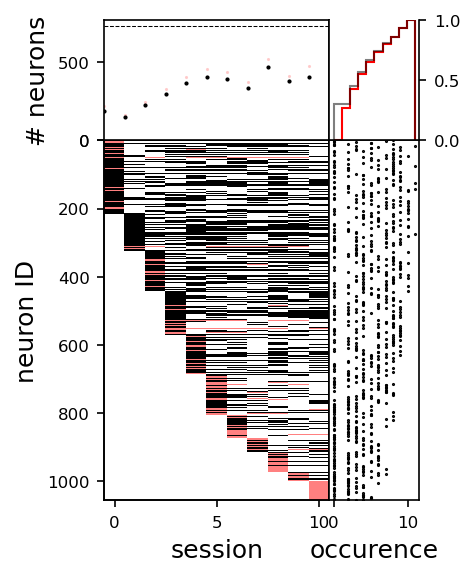

In [101]:
# display neuron occurence statistics (counter-clockwise, starting top-left):
# the number of neurons per session,
# the sessions in which each neuron was detected
# the number of active sessions per neuron
# and the cumulative distribution of active sessions per neuron
m.plot_neuron_numbers()

using existing registration results...
matched: 272, non-matched in ref: 187, non-matched in this: 164
plotting...
first half done: 1.091
done. time taken: 2.148


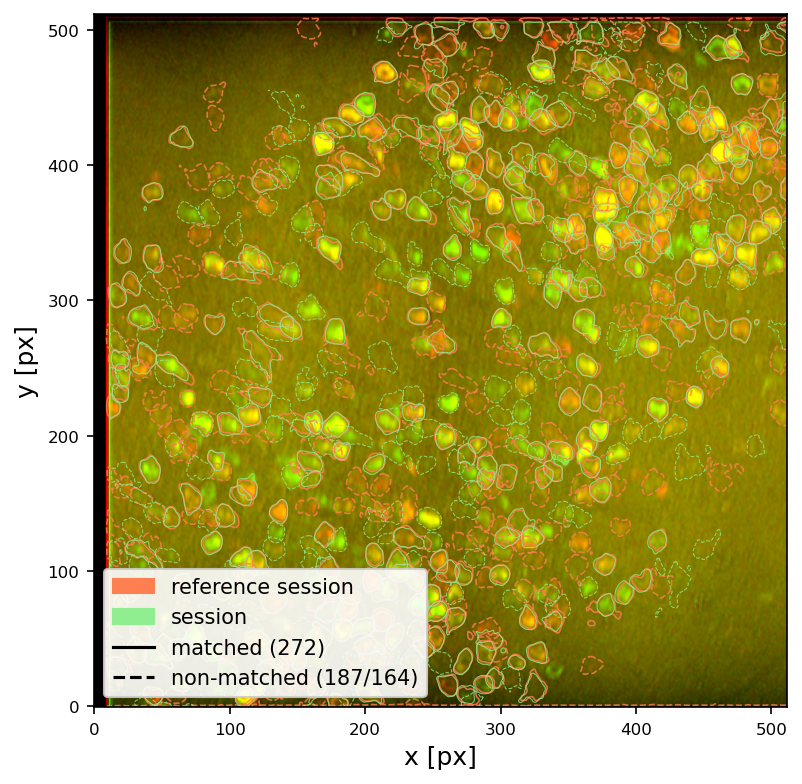

In [102]:
## show the matching results for sessions s_ref and s
m.plot_matches(s_ref=5, s=6)

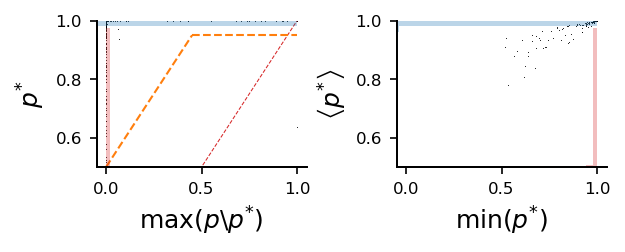

In [112]:
## plot match probabilities for all registered neurons
m.plot_p_match()

### Plotting ROI and cluster statistics of matching ###


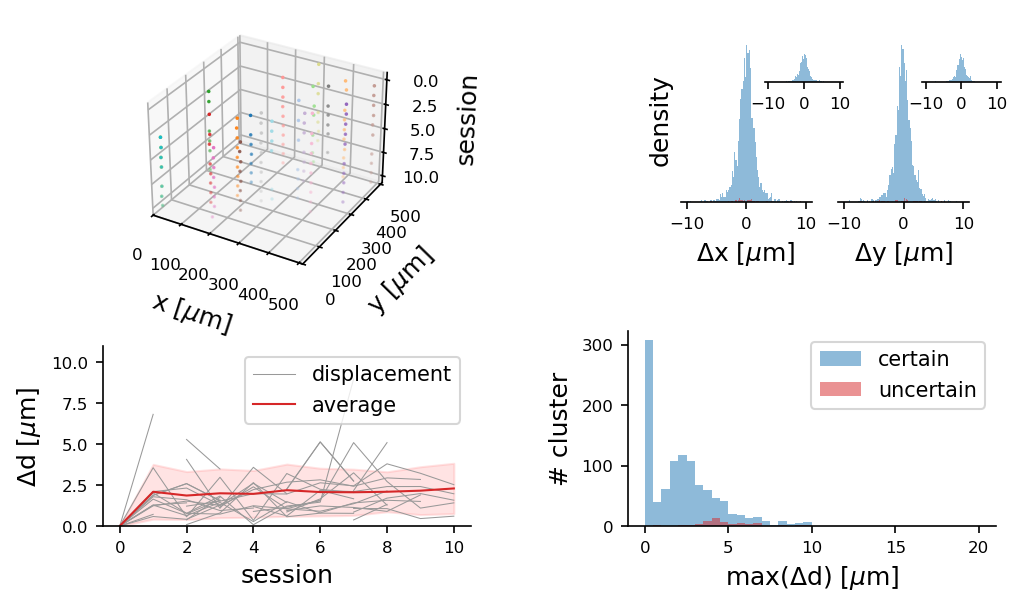

In [108]:
# plot cluster positions of randomly selected neurons and
# shift distributions of matched neurons
m.plot_cluster_stats()

### Plotting matching score statistics ###


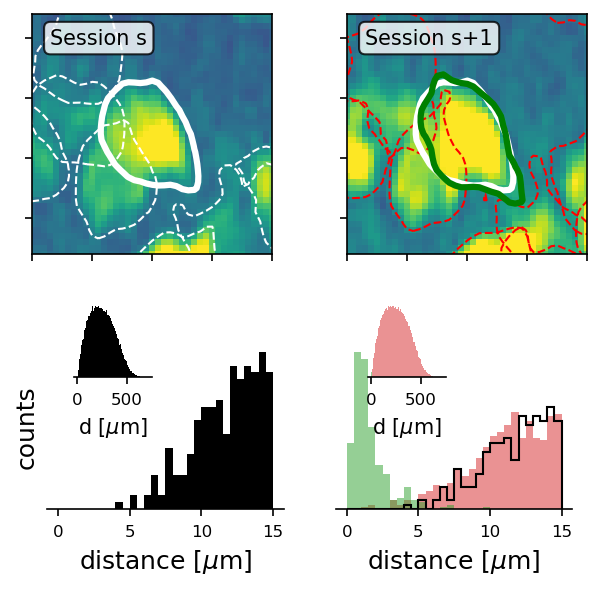

In [61]:
## displays an example of a neuron match
m.plot_match_statistics(5, 6)

## Choosing proper correlation value

In [ ]:
from neuron_tracking.utils_new.footprint_correlation import (
    _centroid_from_array,
    #     calculate_footprint_correlation,
)
import matplotlib.pyplot as plt


def plot_footprints_and_maps(A1, A2, gamma=0.5):

    A1_dense = A1.reshape(512, 512).toarray()
    A2_dense = A2.reshape(512, 512).toarray()
    cm = _centroid_from_array(A1_dense)
    m = 20
    dims = (512, 512)
    x_lims = (int(max(0, cm[1] - m)), int(min(dims[1], cm[1] + m)))
    y_lims = (int(max(0, cm[0] - m)), int(min(dims[0], cm[0] + m)))

    # shifts
    # A1 = mm.session_alignment["A"][str(s1)][:, n1]
    # A2 = mm.session_alignment["A"][str(s2)][:, n2]
    C_max, _, shift, maps = calculate_img_correlation(
        A1, A2, gamma=gamma, return_maps=True
    )

    # # 3) shifted by correlation shift
    # axes[2].contour(A1, levels=levels_A1, colors="k", linewidths=1.0)
    # axes[2].contour(A2_corr, levels=levels_A2, colors="r", linewidths=1.0)
    # axes[2].set_title(f"3) A2 shifted by shift\n(dy={dy_s:.2f}, dx={dx_s:.2f})")

    for ax in axes:
        ax.set_aspect("equal")
        ax.set_xlim(x_lims)
        ax.set_ylim(y_lims)
        ax.invert_yaxis()

    ### ---- MAPS ----
    ax = fig.add_subplot(234)
    im = ax.imshow(maps["overlap_cosine_map"], cmap="viridis", vmin=0.0, vmax=1.0)
    # plt.setp(ax, xlim=[512 - m, 512 + m], ylim=[512 - m, 512 + m])
    # plt.colorbar(im)

    ax = fig.add_subplot(235)
    im = ax.imshow(maps["overlap_coeff_map"], cmap="viridis", vmin=0.0, vmax=1.0)
    # plt.setp(ax, xlim=[512 - m, 512 + m], ylim=[512 - m, 512 + m])

    ax = fig.add_subplot(236)
    # im = ax.imshow(overlap_cosine_map, cmap="viridis", vmin=0.0, vmax=1.0)
    im = ax.imshow(maps["robust_map"], cmap="viridis", vmin=0.0, vmax=1.0)
    # plt.setp(ax, xlim=[512 - m, 512 + m], ylim=[512 - m, 512 + m])
    # plt.colorbar(im)

    plt.show()

In [ ]:
%matplotlib widget
plt.close("all")
# mm.save_registration()
# mm.load_registration(str(mouse_path / "matching" / "neuron_registration.hdf5"))
# mm.plot_footprints(5)
fig = mm.find_confusion_candidates(confusion_distance=1,ct_max=2,use_plotly=False)

In [ ]:
from scipy.ndimage import shift as ndi_shift

from neuron_tracking.utils_new.footprint_correlation import (
    _centroid_from_array,
    #     calculate_footprint_correlation,
)
from neuron_tracking.utils_new.data import (
    calculate_img_correlation,
    # build_remap_from_shift_and_flow,
    # apply_remap,
    shift_sparse_bilinear,
)


def _contour_levels(img, n_levels=6):
    vmax = np.nanmax(img)
    if vmax <= 0:
        return np.array([0.0])
    return np.linspace(0.2 * vmax, 0.9 * vmax, n_levels)


def plot_footprints(A1, A2, gamma=0.5, m=20):

    A1_dense = A1.reshape(512, 512).toarray()
    A2_dense = A2.reshape(512, 512).toarray()
    cm = _centroid_from_array(A1_dense)
    cm2 = _centroid_from_array(A2_dense)
    dims = (512, 512)
    x_lims = (int(max(0, cm[1] - m)), int(min(dims[1], cm[1] + m)))
    y_lims = (int(max(0, cm[0] - m)), int(min(dims[0], cm[0] + m)))

    C_max, _, shift = calculate_img_correlation(A1, A2, gamma=gamma, crop=True)
    ds = np.sqrt(np.sum([s**2 for s in shift]))
    print(f"correlation shift {ds=}, (dy, dx): {shift} with C_max={C_max}")

    print("p_same:", mm.f_same(ds, C_max))
    # dy_c, dx_c = shift
    # A2_shifted = apply_remap(
    #     A2.reshape(512, 512),
    # )
    A2_shifted = ndi_shift(
        A2_dense,
        shift=shift,
        order=1,
        mode="constant",
        cval=0.0,
        prefilter=False,
    )

    # print("shift:", shift)
    cm_shift = tuple(c1 - c2 for c1, c2 in zip(cm, cm2))
    print("vs", cm_shift)
    A1_shifted = shift_sparse_bilinear(A1.reshape(512, 512), -shift[0], -shift[1])
    # A2_cm_shifted = ndi_shift(
    #     A2_dense,
    #     shift=cm_shift,
    #     order=1,
    #     mode="constant",
    #     cval=0.0,
    #     prefilter=False,
    # )

    levels_A1 = _contour_levels(A1_dense)
    levels_A2 = _contour_levels(A2_dense)

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(131)
    ax.contour(A1_dense, levels=levels_A1, colors="k", linewidths=1.0)
    ax.contour(A2_dense, levels=levels_A2, colors="r", linewidths=1.0)
    ax.set_aspect("equal")
    ax.set_xlim(x_lims)
    ax.set_ylim(y_lims)
    ax.invert_yaxis()

    ax = fig.add_subplot(132)
    ax.contour(A1_dense, levels=levels_A1, colors="k", linewidths=1.0)
    ax.contour(A2_shifted, levels=levels_A2, colors="r", linewidths=1.0)
    ax.set_aspect("equal")
    ax.set_xlim(x_lims)
    ax.set_ylim(y_lims)
    ax.invert_yaxis()

    ax = fig.add_subplot(133)
    ax.contour(A1_shifted.toarray(), levels=levels_A1, colors="k", linewidths=1.0)
    ax.contour(A2_dense, levels=levels_A2, colors="r", linewidths=1.0)
    ax.set_aspect("equal")
    ax.set_xlim(x_lims)
    ax.set_ylim(y_lims)
    ax.invert_yaxis()
    plt.show()

In [ ]:
mm.cluster_data["assignments"][(c1, c2), :].T

In [ ]:
"""
** not working yet... sure match (87,494, sessions 1,3) with p=1 is not considered at all and new cluster is formed instead....
* embed function properly in match method
* test for calculating correlations in one session
* ensure (efficient) parallel computin
* run completely
* THEN!:
    * look at silence redetection (build session-dependent map of footprints (existing+constructed))
    * rewrite detection method to take footprints as input and run detection accordingly (refit)

    TODO:
        * check union handover: possible otherwise? -> bad previous match (despite good correlation) causes further matching to be tainted. maybe depending on correlation?
"""

# 494 87
c1 = 87
c2 = 494
# 519 87
print(mm.cluster_data["assignments"][(c1, c2), :].T)
# c2 = c1
# c1 = c2
s1 = 1
s2 = 3

n1 = mm.cluster_data["assignments"][c1, s1]
n2 = mm.cluster_data["assignments"][c2, s2]
print(n1, n2)
A1 = mm.session_alignment["A"][str(s1)][:, n1]
A2 = mm.session_alignment["A"][str(s2)][:, n2]
# C_max, _, shift = calculate_img_correlation(
#     A1, A2, crop=True, mode="cosine_union", gamma=0.1
# )
# cm1 = _centroid_from_array(A1.reshape(512, 512).toarray())
# cm2 = _centroid_from_array(A2.reshape(512, 512).toarray())
# cm1 - cm2
# print(C_max)
# print(cm1, cm2)
# plot_footprints_and_maps(A1, A2)
# print(shift)
plot_footprints(A1, A2, gamma=0.1, m=20)

In [ ]:
shift = (-2.0, 1.0)
%timeit ndi_shift(A2_dense,shift=shift,order=1,mode="constant",cval=0.0,prefilter=False)
%timeit shift_sparse_bilinear(A2.reshape(512,512),shift[0],shift[1])

In [ ]:
s = (-0.06795501532871384, -4.897850714767657)
ds = np.sqrt(sum(i**2 for i in s))
# mm.f_same(ds, 0.808)
mm.f_same(3.0, 0.90)

In [ ]:
# %timeit footprint_match_all(A1_crop,A2_crop,thr1=0.0,thr2=0.0,expected_shift=None,max_shift_radius=None,return_maps=True)
# calculate_footprint_correlation(A1,A2,thr1=0.0,thr2=0.0)
%timeit calculate_footprint_correlation(A1,A2,thr1=0.0,thr2=0.0)

In [ ]:
# A1 = A1.toarray()
# A2 = A2.toarray()
# %timeit calculate_img_correlation(A1,A2,crop=True,shift=True,binary=False)
# %timeit calculate_img_correlation(A1,A2,crop=True,shift=True,binary=False, mode="cosine_union", gamma=0.5)
# %timeit calculate_img_correlation(A1,A2,crop=True,shift=True,binary=False, mode="correlation", gamma=0.5)

calculate_img_correlation(
    A1, A2, crop=True, shift=True, binary=False, mode="cosine_union", gamma=0.5
)
calculate_img_correlation(
    A1, A2, crop=True, shift=True, binary=False, mode="correlation", gamma=0.5
)

# Silent redetection

In [ ]:
root_dir = Path.cwd().parents[2]
if not root_dir in sys.path:
    sys.path.insert(0, str(root_dir))
print("Root dir:", root_dir)

In [ ]:
from scipy import sparse
from utils import load_data

"""
    saving strings currently fails: cuts off at fixed number of characters
    -> adjust saving method
"""
# define session for which redetection should be run
s_redetect = 5  # throw into function argument

## load data from that session

session_alignment = getattr(mm, mm.results[0])
print(session_alignment["file_paths"])
ld = load_data(session_alignment["file_paths"][s_redetect])
T = ld["C"].shape[1]
dims = ld["Cn"].shape
## hand over calcium data (according to cluster IDs)
cluster_data = getattr(mm, mm.results[1])

In [ ]:
this_data.idx_eval.sum()

In [ ]:
nC, nS = cluster_data["assignments"].shape
assignments = cluster_data["assignments"][:, s_redetect]
isActive = assignments >= 0
c_idx = np.where(isActive)[0]
n_idx = assignments[c_idx]

idxes = {
    "in": {
        "active": np.zeros(nC, "bool"),
        "silent": np.zeros(nC, "bool"),
        "match_to_c": c_idx,  # indexing of matching cluster number
        "match_to_n": n_idx,  # indexing to session neuron number
    },
    "out": {
        "active": None,
        "silent": None,
    },
}

dataIn = {
    "A": sparse.csc_matrix(
        (np.prod(dims), nC)
    ),  ## these can be taken from session_alignment
    "C": np.random.rand(
        nC, T
    ),  ## these have to be taken from loaded data / random initialization
    "b": np.random.rand(
        np.prod(dims), 1
    ),  ## this has to be shifted (or just assumed random, as lots changes anyway!)
    "f": np.random.rand(1, T),  ## this has to be random? or taken from data?
}

idxes["in"]["nSilent"] = (~isActive).sum()
idxes["in"]["nActive"] = isActive.sum()
idxes["in"]["active"][: idxes["in"]["nActive"]] = True
idxes["in"]["silent"][idxes["in"]["nActive"] :] = True

print("silent:", idxes["in"]["nSilent"], "active:", idxes["in"]["nActive"])

dataIn["A"][:, : idxes["in"]["nActive"]] = session_alignment["A"]

In [ ]:
(session_alignment["A"][str(s_redetect)].getnnz(axis=0) > 10).sum()
# session_alignment.keys()

In [ ]:
np.save("test.npy", mm.session_alignment)

In [ ]:
paths = sorted(mouse_path.glob("*/neuron_detection*"))

reference_data = mm.preprocess_data(from_file=paths[1])
this_data = mm.preprocess_data(from_file=paths[2])

In [ ]:
from scipy import signal

A1 = mm.reference_data.A[:, NN_idx[0][i]]
A2 = mm.this_data.A[:, NN_idx[1][i]]
def corr_fast(A1,A2):
    C = signal.convolve(A1 - A1.mean(), A2[::-1, ::-1] - A2.mean(), mode="same") / (
        np.prod(dims) * A1.std() * A2.std()
    )
    return C
# C.max()
%timeit corr_fast(A1.toarray(),A2.toarray())